# k-moyennes ou k-means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
%matplotlib inline

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Datasets

Considérons quelques bases de données pour illustrer le comportement de l'algorithme des k-moyennes.

#### 1. Utilisez les méthodes `sklearn.datasets.make_blobs`,  `sklearn.datasets.make_moons` et  `sklearn.datasets.make_circles` pour générer 3 jeux de données contenant 1000 exemples chacun avec le `random_state` choisi à la valeur `42`. Pour les deux méthodes `make_moons` et `make_circles`, mettez le niveau de bruit à `0.05`. Pour la méthode `make_circles` choisissez un facteur de `0.4`. Dans tous les cas, ne conservez que les instances et pas les étiquettes générées.

In [2]:
from sklearn.datasets import make_blobs, make_moons, make_circles
#help(make_blobs)

In [3]:

#help(make_blobs)
n = 1000
blobs_X,_= make_blobs(n,random_state = 42)
moons_X,_ = make_moons(n,random_state = 42, noise = 0.05)
circles_X,_ = make_circles(n,random_state = 42, noise = 0.05, factor = 0.4)

#### 2. Visualisez les données générées précédemment dans 3 graphiques différents. Combien de groupes semble-t-il y avoir dans chaque cas ? Lesquels ?

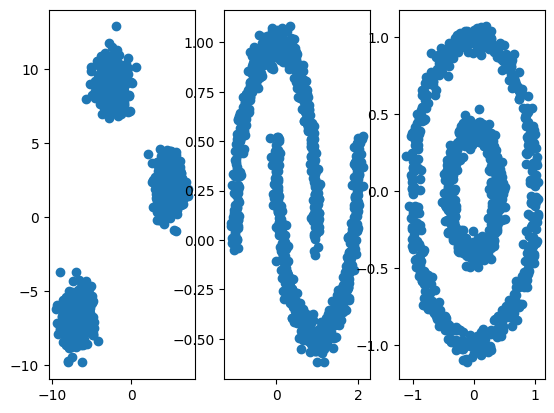

In [4]:
plt.subplot(1,3,1)
plt.scatter(blobs_X[:,0],blobs_X[:,1])
plt.subplot(1,3,2)
plt.scatter(moons_X[:,0],moons_X[:,1])
plt.subplot(1,3,3)
plt.scatter(circles_X[:,0],circles_X[:,1])

Pour les blobs, il y aurait 3 groupes approximativement centrés en (0,9), (5,3) et (-8,-7). Pour les lunes, 2 groupes imbriquées l'une dans l'autre. Pour les cercles, il y aurait 2 groupes, le cercle intérieur et le cercle extérieur.

#### 3. Utilisez l'algorithme `sklearn.cluster.KMeans` pour identifier des groupes dans les données précédentes. Pour chaque dataset, utilisez le k que vous avez identifié en question 2. Visualisez les résultats en colorant les points en fonction de leur appartenance aux différents groupes dans 3 nouveaux graphiques. Que constatez-vous ? Cela vous semble-t-il notmal ? Justifiez.

In [4]:
from sklearn.cluster import KMeans
blobs_groups = KMeans(3).fit_predict(blobs_X)
moons_groups = KMeans(2).fit_predict(moons_X)
circles_groups = KMeans(2).fit_predict(circles_X)

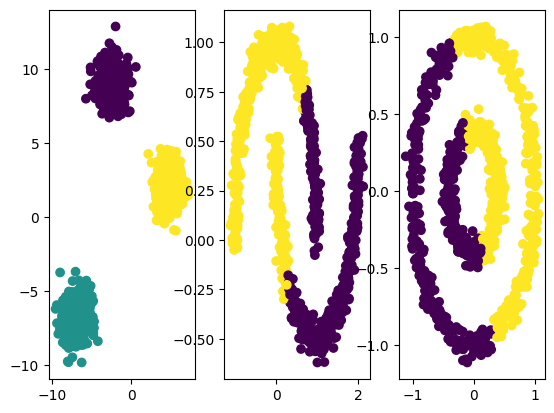

In [12]:
plt.subplot(1,3,1)
plt.scatter(blobs_X[:,0],blobs_X[:,1],c=blobs_groups)
plt.subplot(1,3,2)
plt.scatter(moons_X[:,0],moons_X[:,1],c=moons_groups)
plt.subplot(1,3,3)
plt.scatter(circles_X[:,0],circles_X[:,1],c=circles_groups)

Si l'algorithme des k-moyennes marche bien sur les blobs, il ne semble pas retrouver les groupes des lunes et des cercles. Ce n'est pas surprenant. En effet, l'algorithme des k-moyennes est basé sur une notion de distance et cherche à trouves des centres représentatifs des données. Malheureusement, dans le cas des lunes, les centres qui correspondraient théoriquement au partitionnement idéal en deux lunes conduisent en réalité à un partitionnement bien différent puisque certains exemples sont plus proches du centre qui ne correspond pas à leur groupe. De la même façon, dans le cas des cercles, les centres qui correspondraient théoriquement au partitionnement idéal en deux cercles concentriques sont confondus en (0,0), l'algorithme des k-moyennes ne peut donc pas les identifier. Il cherche, à la place, à minimiser l'inertie et obtient des centres bien différents.

## Dataset MNIST

Nous allons maintenant nous intéresser au dataset MNIST, un dataset contenant 70000 images de taille 28x28 de chiffres manuscrits allant de 0 à 9. Nous allons étudier une version modifiée de ce dataset où les images ont été projetées dans un espace de faible dimension (ex via ACP)

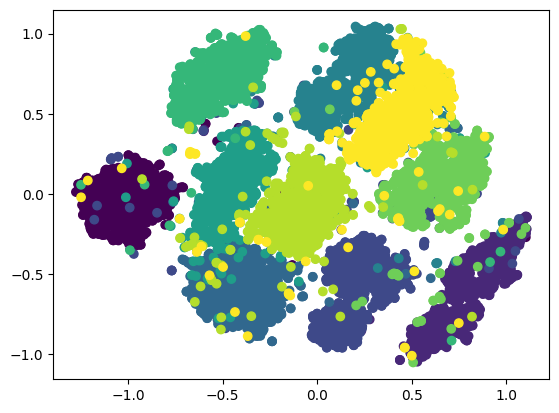

In [13]:
X = pd.read_csv("../MNIST-20260105/mnist_data.csv")/100
y = pd.read_csv("../MNIST-20260105/mnist_labels.csv",dtype=int).squeeze()
plt.scatter(X["tSNE1"],X["tSNE2"],c=y)

#### 4. Utilisez l'algorithme `sklearn.cluster.KMeans` pour identifier des groupes dans les données MNIST en utilisant les paramètres suivants : `n_clusters=10`, `init='random'`, `n_init=1`. Visualisez les clusters obtenus.

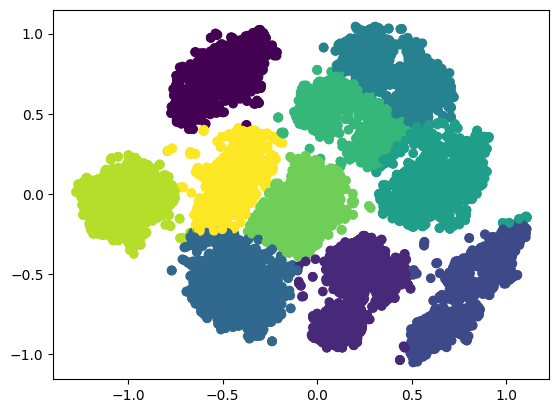

In [18]:
mnist_groups_1 = KMeans(n_clusters=10, init='random', n_init=1).fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=mnist_groups_1)

#### 5. Répétez 4 fois la question 4 afin d'obtenir 4 nouveaux partitionnements (donnez des noms différents aux différents partitionnements, vous en aurez besoin par la suite). Le résultat est-il stable ? Cela vous semble-t-il normal ? Justifiez.

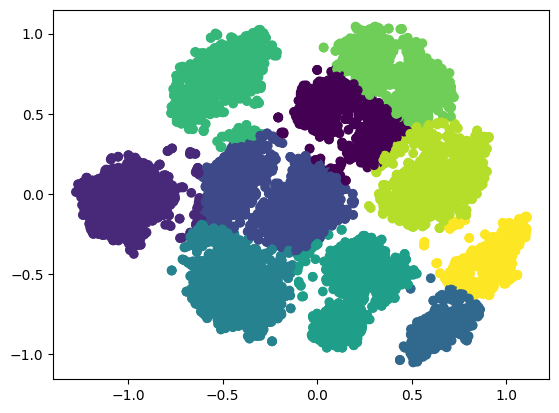

In [26]:
mnist_groups_2 = KMeans(n_clusters=10, init='random', n_init=1).fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=mnist_groups_2)

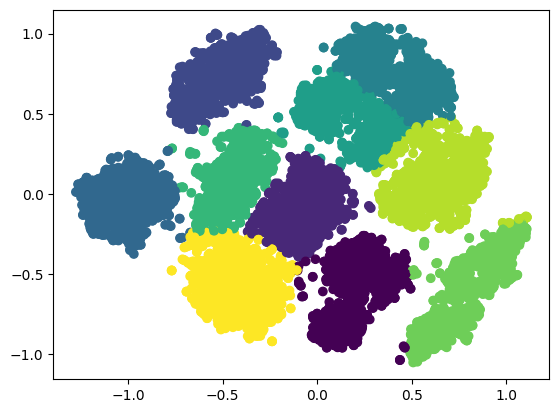

In [28]:
mnist_groups_3 = KMeans(n_clusters=10, init='random', n_init=1).fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=mnist_groups_3)

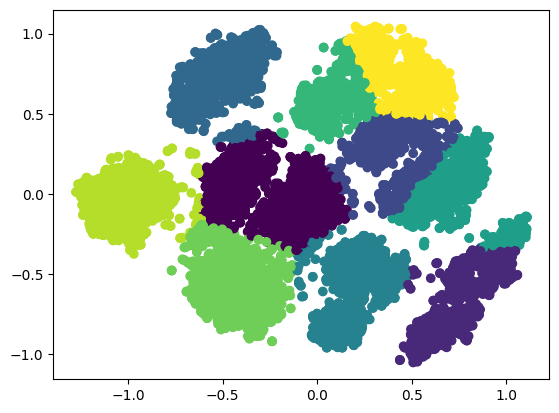

In [29]:
mnist_groups_4 = KMeans(n_clusters=10, init='random', n_init=1).fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=mnist_groups_4)

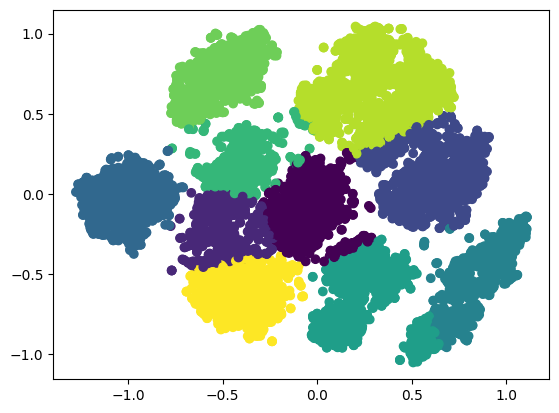

In [23]:
mnist_groups_5 = KMeans(n_clusters=10, init='random', n_init=1).fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=mnist_groups_5)

Le résultat obtenu n'est pas stable, on obtient plusieurs partitionnements différents. Cela n'est pas surprenant. En effet, nous savions déjà que l'algorithme des k-moyennes pouvait tomber dans des minimums locaux en fonction de l'initialisation considérée. C'est ce qu'il se passe ici étant donné que nous avons désactivé tous garde-fous proposés par sklearn (initialisations multiples, k-means++). Cela démontre bien l'instabilité de l'approche et souligne la prudence dont il faut faire preuve lors de l'interprétation des résultats.

#### 6. Dans la question précédente, vous avez, normalement, trouvé des partitionnements différents. Plusieurs méthodes existent pour stabiliser le résultat. La première d'entre-elles consiste à considérer plusieurs initialisations différentes (pour éviter les minimums locaux) et à ne conserver que le résultat qui donne la meilleure inertie. C'est le paramètre `n_init` qui contrôle cette information, il est généralement mis à `10` dans `sklearn`, c'est un nombre raisonnable d'essai pour les initialisations. La seconde méthode est d'utiliser l'initialisation dite de `kmeans++` plutôt que l'initialisation `random`. Renseignez-vous sur cette initialisation et décrivez son fonctionnement.

L'algorithme k-means++ permet d'obtenir des centres initiaux qui sont plus éloignés les uns des autres (on parle d'augmentation de la diversité) ce qui permet, en général, d'obtenir de meilleurs groupes. En effet, si deux centres sont très proches, certains groupes peuvent être faussement subdivisés. Par exemple, dans l'exemple des blobs, si on a deux centres dans le groupe en bas à gauche et un centre entre les deux groupes situés en haut à droite, l'algorithme des k-moyennes va probablement diviser le groupe en bas à gauche en deux sous-groupes tandis qu'il va réunir les deux groupes du haut en un seul groupe.
L'algorithme k-means++ fonctionne en 4 étapes pour choisir les centres initiaux :

1. Choisir un premier centre aléatoirement.

2. Calculer, pour chaque exemple, la distance au carré qui le sépare du centre dont il est le plus proche.

3. Choisir aléatoirement un nouveau centre en considérant que la probabilité de choisir un exemple comme nouveau centre est proportionnelle à la distance calculée dans l'étape 2. Cela signifie que les exemples situés loin de tous les centres déjà choisis ont plus de chances d'être sélectionnés.

3. Répéter les étapes 2 et 3 jusqu'à obtention du nombre de centres désiré.


#### 7.  Utilisez de nouveau l'algorithme `sklearn.cluster.KMeans` sur les données MNIST avec, cette fois, les paramètres `n_clusters=10`, `init='k-means++'`, `n_init=10`. Le résultat est-il plus stable ?

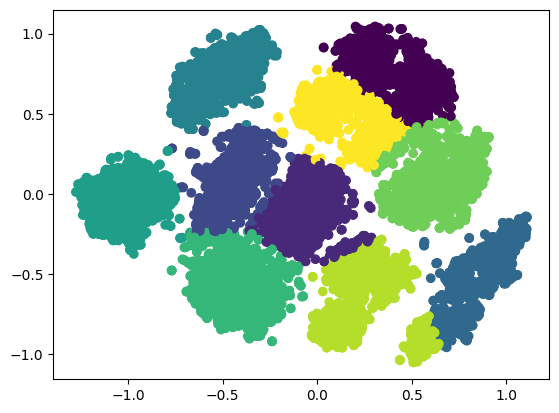

In [30]:
mnist_groups = KMeans(n_clusters=10).fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=mnist_groups)

## Mesures de Performance

Maintenant que l'algorithme est plus stable, nous pouvons essayer de déterminer le nombre de groupes $k$ qui donnerait les meilleurs résultats. En effet, dans l'exemple précédent, certains groupes de nombres sont si proches qu'il semble difficile de les séparer. Il ne faut donc pas s'attendre à ce qu'un algorithme de partitionnement puisse les distinguer. Par conséquent, utiliser `10` groupes n'est peut-être pas optimal d'un point de vu partitionnement. Dans la suite, nous allons considérer deux scores différents : l'`inertie` que nous avons vue durant le cours et le `score silhouette`.

#### 8. Présentez rapidement le `sklearn.metrics.silhouette_score` en expliquant la méthode de calcul de ce score et l'interprétentation des différentes valeurs qu'il peut prendre.

In [33]:
from sklearn.metrics import silhouette_score
inertie = []
sil_score = []
k_range = range(2,31)
for k in k_range:
    clust = KMeans(k)
    clust.fit(X)
    inertie.append(clust.inertia_)
    sil_score.append(silhouette_score(X,clust.predict(X)))

#### 9. Tracez la courbe de l'inertie et du silhouette score des partionnements appris par l'algorithme des k-moyennes sur les données MNIST lorsque l'on fait varier le nombre de groupes k entre 2 et 30 (vous pouvez vous arrêter à 20 si cela prend trop de temps).

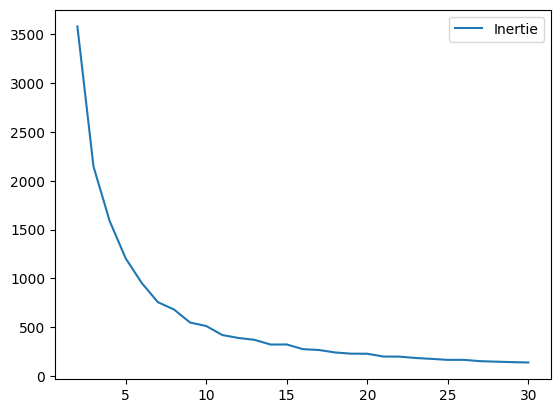

In [32]:
plt.plot(k_range,inertie,label="Inertie")
plt.legend()

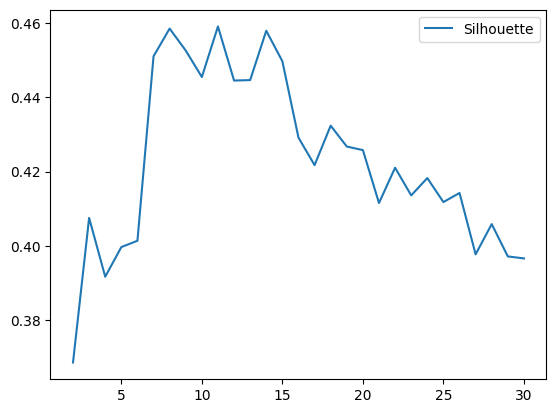

In [34]:
plt.plot(k_range,sil_score,label="Silhouette")
plt.legend()

#### 10. Quelle valeur de `k` vous semble la plus appropriée pour avoir la meilleure inertie ? pour avoir le meilleur silhouette score ? Est-ce la même valeur ? Qu'en déduisez-vous ?

L'inertie semble suggérer l'utilisation d'une valeure de k très élevée pour être minimisée. Ce n'est pas surprenant puisque si le nombre de centre est égal aux nombre d'exemple, on peut utiliser un exemple par centre et l'inertie est nulle. Pour utiliser ce score pour déterminer le nombre de clusters correct, il faut utiliser la méthode dite du coude (elbow en anglais). L'idée sous-jacente est de sélectionner un nombre de groupes à partir duquel l'ajout d'un nouveau groupe ne change plus significativement la valeur de l'inertie. Ici, il s'agirait de choisr k aux alentours de 10.
Contrairement à l'inertie, le score de silhouette présente un pic maximal distinct aux alentours de 10 groupes. Comme nous souhaitons maximiser ce score, nous allons sélectionner k à 10.
L'inertie (sans elbow) et le score de silhouette suggèrent des nombres de clusters différents. Le choix du score que l'on cherche à optimiser a donc une importance certaine sur le résultat obtenu. Le fait que l'inertie avec l'approche elbow suggère le même nombre de groupes que le score de silhouette est, ici, plus une coïncidence heureuse qu'autre chose. Ce comportement ne va pas forcément se retrouver sur d'autres jeux de données.


#### 11. Utilisez la valeur de `k` suggérée par le silhouette_score et apprenez un nouveau partitionnement. Utilisez la méthode `sklearn.metrics.cluster.contingency_matrix` pour obtenir une matrice de contingence. Que constatez-vous ?

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
clust = KMeans(10)
# 
clust.fit(X)
preds = clust.predict(X)
pd.DataFrame(contingency_matrix(y,preds))

,0,1,2,3,4,5,6,7,8,9
0,1,0,0,11,1,965,0,1,1,0
1,0,0,3,4,1,0,0,0,604,523
2,9,1,958,10,5,12,2,23,10,2
3,12,7,17,3,960,4,0,6,0,1
4,3,63,2,9,0,0,898,0,7,0
5,639,2,1,63,138,45,2,2,0,0
6,0,0,0,944,0,9,2,0,2,1
7,1,37,9,0,0,0,4,946,22,9
8,857,5,36,4,56,3,5,7,0,1
9,3,864,4,1,13,15,73,31,1,4


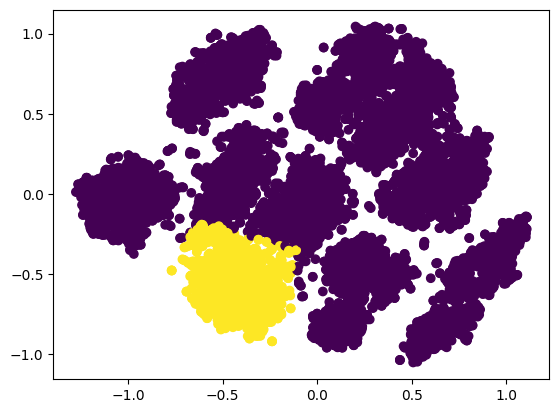

In [41]:
plt.scatter(X["tSNE1"],X["tSNE2"],c=np.where(preds==4,1,-1))